In [203]:
import pandas as pd
import numpy as np
df=pd.read_pickle(f"../df24.pkl")
y=df[['hba1c']]
X=df.drop(columns=['dm','glu','hba1c'])

In [204]:
X.shape

(4325, 27)

In [205]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# =========================
# 2. 표준화 (반드시 해야 함)
# =========================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# =========================
# 3. PLS (1 component)
# =========================
pls = PLSRegression(n_components=1)
pls.fit(X_scaled, y_scaled)

# =========================
# 4. z1 생성
# =========================
z1 = pls.x_scores_[:, 0]   # 1차원 latent score

df['z1'] = z1

# =========================
# 5. HbA1c 예측 성능 확인
# =========================
y_pred_scaled = pls.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

r2 = r2_score(y, y_pred)
print("R2 (z1 → HbA1c):", r2)

# =========================
# 6. z1과 HbA1c 상관
# =========================
corr = np.corrcoef(z1, y['hba1c'].values)[0, 1]
print("Correlation(z1, HbA1c):", corr)

# =========================
# 7. 각 lifestyle 변수 가중치 확인
# =========================
weights = pd.Series(pls.x_weights_[:, 0], index=X.columns)
print("\nPLS weights:")
print(weights.sort_values(ascending=False))

R2 (z1 → HbA1c): 0.18656445100460228
Correlation(z1, HbA1c): 0.4319310720527089

PLS weights:
age             0.451955
wc              0.360735
sbp             0.275157
wk_break        0.263826
bmi             0.247412
wk_veg1         0.238797
wk_veg2         0.223714
job             0.174426
tg              0.157161
wt              0.119564
wk_fruit        0.048509
wk_lunch        0.035344
wk_smk          0.032671
wk_dinner       0.028238
wk_walk         0.019918
wk_sleep       -0.015086
wk_mvpa_work   -0.053747
wk_alc         -0.059626
sex            -0.075922
stress         -0.106770
ht             -0.129212
wk_mvpa_play   -0.132822
income         -0.153131
ldl            -0.168189
chol           -0.180310
hdl            -0.238326
edu            -0.278395
dtype: float64


In [206]:
df['dm_binary'] = (df['dm'] == 2).astype(int)

In [207]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pandas as pd

# -----------------------------
# 1. 설명변수 선택
# -----------------------------
X = df[['z1', 'hba1c']]

# -----------------------------
# 2. 스케일링
# -----------------------------
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# ⭐ 원래 index 유지
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=['z1_std', 'hba1c_std'],
    index=df.index
)

# -----------------------------
# 3. 상수항 추가
# -----------------------------
X_scaled = sm.add_constant(X_scaled)

# -----------------------------
# 4. 로지스틱 회귀
# -----------------------------
model = sm.Logit(df['dm_binary'], X_scaled)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.151265
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:              dm_binary   No. Observations:                 4325
Model:                          Logit   Df Residuals:                     4322
Method:                           MLE   Df Model:                            2
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.6572
Time:                        16:50:54   Log-Likelihood:                -654.22
converged:                       True   LL-Null:                       -1908.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3996      0.124    -27.348      0.000      -3.643      -3.156
z1_std         0.5166      0.

In [208]:
# 1. z1을 4분위로 나누기
# -----------------------------
df['z1_quartile'] = pd.qcut(df['z1'], q=4, labels=['Q1','Q2','Q3','Q4'])

# -----------------------------
# 2. 분위수별 HbA1c 평균 계산
# -----------------------------
group_mean = df.groupby('z1_quartile')['hba1c'].mean()
group_sem = df.groupby('z1_quartile')['hba1c'].sem()  # 표준오차

print(group_mean)

z1_quartile
Q1    5.231885
Q2    5.486031
Q3    5.819334
Q4    6.029325
Name: hba1c, dtype: float64


C:\Users\cmc\AppData\Local\Temp\ipykernel_85980\803544960.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mean = df.groupby('z1_quartile')['hba1c'].mean()
C:\Users\cmc\AppData\Local\Temp\ipykernel_85980\803544960.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sem = df.groupby('z1_quartile')['hba1c'].sem()  # 표준오차


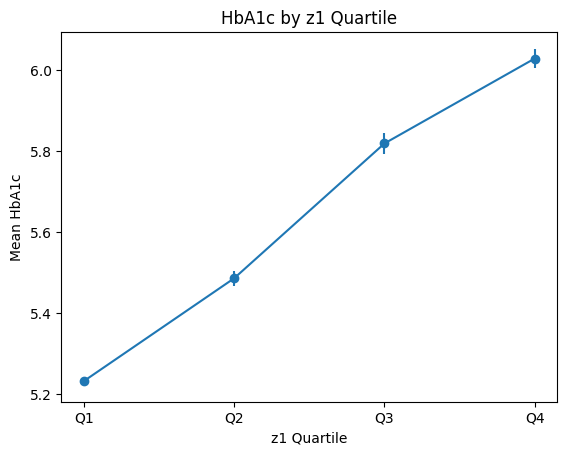

In [209]:
import matplotlib.pyplot as plt

plt.figure()

plt.errorbar(
    x=group_mean.index,
    y=group_mean.values,
    yerr=group_sem.values,
    marker='o'
)

plt.xlabel('z1 Quartile')
plt.ylabel('Mean HbA1c')
plt.title('HbA1c by z1 Quartile')

plt.show()

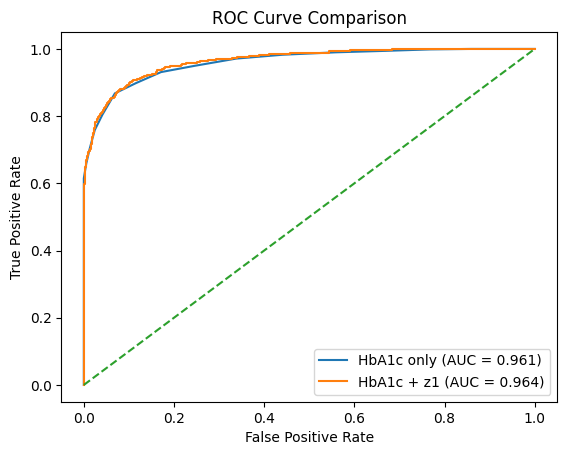

AUC (HbA1c only): 0.9607589168353271
AUC (HbA1c + z1): 0.9644419316932881
AUC difference: 0.0036830148579609645


In [210]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# -----------------------------
# 1. 종속변수
# -----------------------------
y = df['dm_binary']

# -----------------------------
# 2. Model 1: HbA1c only
# -----------------------------
X1 = sm.add_constant(df[['hba1c']])
model1 = sm.Logit(y, X1).fit(disp=0)

# 예측 확률
y_pred1 = model1.predict(X1)

# ROC 계산
fpr1, tpr1, _ = roc_curve(y, y_pred1)
auc1 = roc_auc_score(y, y_pred1)

# -----------------------------
# 3. Model 2: HbA1c + z1
# -----------------------------
X2 = sm.add_constant(df[['hba1c','z1']])
model2 = sm.Logit(y, X2).fit(disp=0)

y_pred2 = model2.predict(X2)

fpr2, tpr2, _ = roc_curve(y, y_pred2)
auc2 = roc_auc_score(y, y_pred2)

# -----------------------------
# 4. ROC Curve Plot
# -----------------------------
plt.figure()

plt.plot(fpr1, tpr1, label=f'HbA1c only (AUC = {auc1:.3f})')
plt.plot(fpr2, tpr2, label=f'HbA1c + z1 (AUC = {auc2:.3f})')

plt.plot([0,1], [0,1], linestyle='--')  # random baseline

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

# -----------------------------
# 5. AUC 출력
# -----------------------------
print("AUC (HbA1c only):", auc1)
print("AUC (HbA1c + z1):", auc2)
print("AUC difference:", auc2 - auc1)

In [211]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# -----------------------------
# 1. 정상 HbA1c subset
# -----------------------------
df_normal = df[
    (df['hba1c'] >= 5.7) | (df['glu'] >= 100)
].copy()
print("Subset size:", len(df_normal))
print("DM prevalence in subset:", df_normal['dm_binary'].mean())

Subset size: 2091
DM prevalence in subset: 0.32950741272118605


In [212]:
# -----------------------------
# 2. 로지스틱 회귀 (z1만 사용)
# -----------------------------
X = df_normal[['z1']]
X = sm.add_constant(X)

y = df_normal['dm_binary']

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

# OR 계산
or_z1 = np.exp(result.params['z1'])
print("OR (z1):", or_z1)

Optimization terminated successfully.
         Current function value: 0.589434
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              dm_binary   No. Observations:                 2091
Model:                          Logit   Df Residuals:                     2089
Method:                           MLE   Df Model:                            1
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                 0.07004
Time:                        16:50:54   Log-Likelihood:                -1232.5
converged:                       True   LL-Null:                       -1325.3
Covariance Type:            nonrobust   LLR p-value:                 2.813e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2080      0.066    -18.246      0.000      -1.338      -1.078
z1             0.4294      0.

In [213]:
X1 = df_normal[['hba1c']]
X1 = sm.add_constant(X1)

model1 = sm.Logit(y, X1)
result1 = model1.fit()

pred1 = result1.predict(X1)
auc1 = roc_auc_score(y, pred1)

print("AUC (HbA1c only):", auc1)

Optimization terminated successfully.
         Current function value: 0.296199
         Iterations 8
AUC (HbA1c only): 0.9218403524717955


In [214]:
X2 = df_normal[['hba1c', 'z1']]
X2 = sm.add_constant(X2)

model2 = sm.Logit(y, X2)
result2 = model2.fit()

pred2 = result2.predict(X2)
auc2 = roc_auc_score(y, pred2)

print("AUC (HbA1c + z1):", auc2)
print("AUC improvement:", auc2 - auc1)

Optimization terminated successfully.
         Current function value: 0.290680
         Iterations 8
AUC (HbA1c + z1): 0.9273492771056898
AUC improvement: 0.0055089246338942965


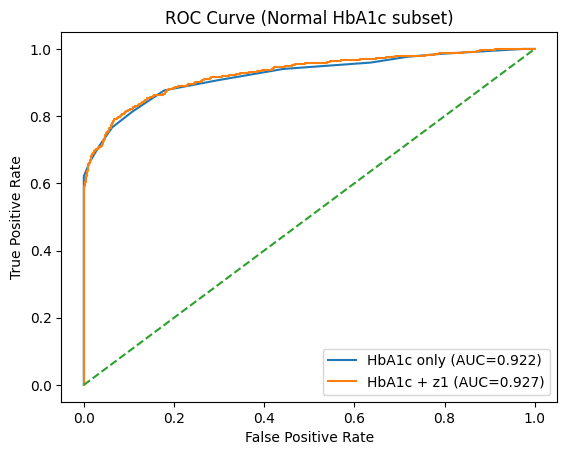

In [215]:
fpr1, tpr1, _ = roc_curve(y, pred1)
fpr2, tpr2, _ = roc_curve(y, pred2)

plt.figure()
plt.plot(fpr1, tpr1, label=f'HbA1c only (AUC={auc1:.3f})')
plt.plot(fpr2, tpr2, label=f'HbA1c + z1 (AUC={auc2:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve (Normal HbA1c subset)")
plt.show()

In [216]:
from sklearn.metrics import roc_auc_score
from scipy import stats
import numpy as np

# 두 모델 예측값: pred1, pred2
# 실제값: y

def auc_delong_test(y_true, pred1, pred2):
    from sklearn.metrics import roc_auc_score
    auc1 = roc_auc_score(y_true, pred1)
    auc2 = roc_auc_score(y_true, pred2)
    diff = auc2 - auc1
    return auc1, auc2, diff

auc1, auc2, diff = auc_delong_test(y, pred1, pred2)
print("AUC1:", auc1)
print("AUC2:", auc2)
print("Difference:", diff)

AUC1: 0.9218403524717955
AUC2: 0.9273492771056898
Difference: 0.0055089246338942965
